# OpenBDAP -- Risposta alla Discussion #10

**Domanda:** Le Spese Correnti stanno comprimendo gli investimenti?

**Link discussion:** https://github.com/dataciviclab/openbdap-saldi-storico-stato/discussions/10



## 0 - Setup: mount Drive e librerie

In [ ]:
import sys, os
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print('Librerie ok.')


Librerie ok.


## 1 - Trova `saldi_storico.parquet`

Cerca in MyDrive, nelle cartelle condivise (`.shortcut-targets-by-id`) e come fallback
in tutto il Drive montato. Sceglie il file con la data di modifica piu recente.


In [ ]:
def find_latest_parquet(filename='saldi_storico.parquet'):
    search_roots = [
        '/content/drive/MyDrive',
        '/content/drive/.shortcut-targets-by-id',
        '/content/drive',
    ]
    found = []
    for root in search_roots:
        if not os.path.exists(root):
            continue
        for r, dirs, files in os.walk(root):
            if filename in files:
                full = os.path.join(r, filename)
                if full not in found:
                    found.append(full)
    if not found:
        raise FileNotFoundError(
            f"\n'\u274c' '{filename}' non trovato nel Drive.\n"
            'Controlla che la cartella DataCivicLab condivisa sia aggiunta '
            'come scorciatoia al tuo Drive.'
        )
    latest = max(found, key=os.path.getmtime)
    print(f'Parquet trovato ({len(found)} copia/e):')
    for f in found:
        marker = ' <- selezionato (piu recente)' if f == latest else ''
        print(f'   {f}{marker}')
    return latest

parquet_path = find_latest_parquet()
df_raw = pd.read_parquet(parquet_path)
print(f'\nShape: {df_raw.shape}')
print('Colonne:', df_raw.columns.tolist())
display(df_raw.head(3))


Parquet trovato (2 copia/e):
   /content/drive/.shortcut-targets-by-id/1E7NSjjroe390piSMuQWJVCVZ8lNb4IPo/DataCivicLab/data/clean/openbdap_rendiconto_saldi_storico/20260226_201148/saldi_storico.parquet
   /content/drive/.shortcut-targets-by-id/1E7NSjjroe390piSMuQWJVCVZ8lNb4IPo/DataCivicLab/data/clean/openbdap_rendiconto_saldi_storico/20260308_152606/saldi_storico.parquet <- selezionato (piu recente)

Shape: (22, 22)
Colonne: ['esercizio_finanziario', 'risparmio_pubblico', 'saldo_netto_da_finanziare', 'indebitamento_netto', 'ricorso_al_mercato', 'avanzo_primario', 'spese_correnti', 'spese_per_interessi', 'spese_in_conto_capitale', 'spese_acquisizione_attivita_finanziarie', 'spese_per_rimborso_prestiti', 'spese_complessive', 'spese_finali', 'spese_finali_netto_att_fin', 'entrate_tributarie', 'entrate_extra_tributarie', 'entrate_alienazioni_patrimoniali_e_riscossioni', 'riscossione_crediti', 'entrate_accensione_prestiti', 'entrate_finali', 'entrate_fin_netto_riscossione_crediti', 'entrate_

,esercizio_finanziario,risparmio_pubblico,saldo_netto_da_finanziare,indebitamento_netto,ricorso_al_mercato,avanzo_primario,spese_correnti,spese_per_interessi,spese_in_conto_capitale,spese_acquisizione_attivita_finanziarie,spese_per_rimborso_prestiti,spese_complessive,spese_finali,spese_finali_netto_att_fin,entrate_tributarie,entrate_extra_tributarie,entrate_alienazioni_patrimoniali_e_riscossioni,riscossione_crediti,entrate_accensione_prestiti,entrate_finali,entrate_fin_netto_riscossione_crediti,entrate_correnti
0,2003,"-23,527,106,344.85","-76,608,438,560.85","-70,589,525,371.85","-333,428,879,750.18","-469,519,795.74","404,491,049,044.85","76,138,918,765.11","61,602,074,235.00","7,116,577,049.00","256,820,441,189.33","722,913,564,469.18","466,093,123,279.85","458,976,546,230.85","355,706,649,246.00","25,257,293,454.00","8,520,742,019.00","1,097,663,860.00","323,025,518,751.18","389,484,684,719.00","388,387,020,859.00","380,963,942,700.00"
1,2004,"-30,341,184,650.00","-63,777,783,304.76","-57,927,611,571.76","-298,880,446,856.76","11,342,166,924.46","423,863,010,729.00","75,119,950,229.22","48,548,637,821.76","6,051,618,598.00","235,102,663,552.00","707,514,312,102.76","472,411,648,550.76","466,360,029,952.76","364,955,511,012.00","28,566,315,067.00","15,112,039,167.00","201,446,865.00","291,025,385,111.36","408,633,865,246.00","408,432,418,381.00","393,521,826,079.00"
2,2005,"-27,020,371,868.32","-58,445,411,507.42","-55,169,109,483.42","-259,929,492,773.42","17,967,721,312.10","437,872,619,916.32","76,413,132,819.52","47,811,091,762.10","6,557,304,682.00","201,484,081,266.00","687,167,792,944.42","485,683,711,678.42","479,126,406,996.42","381,431,229,004.00","29,421,019,044.00","16,386,052,123.00","3,281,002,658.00","259,560,984,207.42","427,238,300,171.00","423,957,297,513.00","410,852,248,048.00"


## 2 - Mappatura e normalizzazione colonne

In [ ]:
ALIASES = {
    'anno':                    ['esercizio_finanziario', 'anno', 'year'],
    'indebitamento_netto':     ['indebitamento_netto'],
    'ricorso_al_mercato':      ['ricorso_al_mercato'],
    'avanzo_primario':         ['avanzo_primario'],
    'spese_correnti':          ['spese_correnti'],
    'spese_per_interessi':     ['spese_per_interessi', 'interessi_passivi'],
    'spese_in_conto_capitale': ['spese_in_conto_capitale', 'spesa_in_conto_capitale'],
    'spese_complessive':       ['spese_complessive', 'spese_totali'],
    'entrate_tributarie':      ['entrate_tributarie'],
    'entrate_correnti':        ['entrate_correnti'],
}

def resolve_cols(df_cols, aliases):
    return {
        logical: next((c for c in candidates if c in df_cols), None)
        for logical, candidates in aliases.items()
    }

colmap = resolve_cols(df_raw.columns.tolist(), ALIASES)
print('Mappatura colonne:')
for logical, real in colmap.items():
    status = f'-> {real}' if real else 'NON TROVATA'
    print(f'  {logical:<30} {status}')
missing = [k for k, v in colmap.items() if v is None]
if missing:
    print(f'\nColonne mancanti: {missing}')


Mappatura colonne:
  anno                           -> esercizio_finanziario
  indebitamento_netto            -> indebitamento_netto
  ricorso_al_mercato             -> ricorso_al_mercato
  avanzo_primario                -> avanzo_primario
  spese_correnti                 -> spese_correnti
  spese_per_interessi            -> spese_per_interessi
  spese_in_conto_capitale        -> spese_in_conto_capitale
  spese_complessive              -> spese_complessive
  entrate_tributarie             -> entrate_tributarie
  entrate_correnti               -> entrate_correnti


In [ ]:
df = pd.DataFrame({
    logical: df_raw[real]
    for logical, real in colmap.items() if real is not None
}).copy()
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df['anno'] = df['anno'].astype('Int64')
df = df.sort_values('anno').reset_index(drop=True)
Y_MIN = int(df['anno'].min())
Y_MAX = int(df['anno'].max())
N     = int(df['anno'].nunique())
print(f'Dataset pronto: {N} anni, {Y_MIN}–{Y_MAX}')
display(df)


Dataset pronto: 22 anni, 2003–2024


,anno,indebitamento_netto,ricorso_al_mercato,avanzo_primario,spese_correnti,spese_per_interessi,spese_in_conto_capitale,spese_complessive,entrate_tributarie,entrate_correnti
0,2003,"-70,589,525,371.85","-333,428,879,750.18","-469,519,795.74","404,491,049,044.85","76,138,918,765.11","61,602,074,235.00","722,913,564,469.18","355,706,649,246.00","380,963,942,700.00"
1,2004,"-57,927,611,571.76","-298,880,446,856.76","11,342,166,924.46","423,863,010,729.00","75,119,950,229.22","48,548,637,821.76","707,514,312,102.76","364,955,511,012.00","393,521,826,079.00"
2,2005,"-55,169,109,483.42","-259,929,492,773.42","17,967,721,312.10","437,872,619,916.32","76,413,132,819.52","47,811,091,762.10","687,167,792,944.42","381,431,229,004.00","410,852,248,048.00"
3,2006,"-45,602,974,733.10","-234,128,614,666.10","30,689,365,339.90","439,557,751,203.07","75,693,732,698.00","39,823,934,288.03","668,505,932,799.10","402,347,500,528.00","431,045,445,133.00"
4,2007,"-32,180,004,416.00","-223,639,678,240.00","44,089,973,785.87","457,766,592,245.27","76,536,004,669.87","54,773,460,056.73","703,733,699,658.00","440,510,285,000.00","473,726,481,136.00"
5,2008,"-55,898,867,792.43","-258,884,895,518.43","21,042,783,602.57","489,192,445,598.82","85,454,219,882.00","64,849,664,010.61","748,515,568,848.43","453,581,106,800.00","486,152,759,507.00"
6,2009,"-74,143,432,966.87","-294,005,262,004.01","995,133,580.47","497,581,776,986.75","79,040,399,516.48","60,706,232,870.25","774,248,005,925.00","441,152,358,367.00","477,326,575,291.99"
7,2010,"-59,259,278,019.66","-288,752,422,280.27","11,533,382,392.49","491,815,839,285.16","75,332,098,407.76","52,547,594,782.11","769,317,140,332.27","443,439,701,579.00","478,369,069,000.00"
8,2011,"-41,657,499,529.18","-243,280,532,386.00","33,521,631,310.00","490,490,407,782.86","79,586,393,694.00","48,813,017,432.14","736,519,195,217.00","452,260,716,000.00","489,884,208,625.00"
9,2012,"-11,896,002,103.00","-266,894,641,954.00","70,033,436,945.00","508,447,573,289.00","88,524,275,790.00","46,829,656,350.00","803,681,032,748.00","482,458,877,000.00","534,343,904,374.00"


## 3 - Metriche derivate

In [ ]:
df['copertura_tributaria']      = df['entrate_tributarie']       / df['spese_correnti']
df['copertura_corrente']        = df['entrate_correnti']         / df['spese_correnti']
df['quota_interessi_trib']      = df['spese_per_interessi']      / df['entrate_tributarie']
df['quota_conto_capitale']      = df['spese_in_conto_capitale']  / df['spese_complessive']
df['quota_corrente']            = df['spese_correnti']           / df['spese_complessive']
df['gap_primario_vs_interessi'] = df['avanzo_primario']          - df['spese_per_interessi']
df['ricorso_su_spese']          = df['ricorso_al_mercato']       / df['spese_complessive']
df['f_deficit']             = df['indebitamento_netto']   < 0
df['f_avanzo_pos']          = df['avanzo_primario']       > 0
df['f_trib_copre']          = df['copertura_tributaria']  >= 1
df['f_corrente_copre']      = df['copertura_corrente']    >= 1
df['f_interessi_gt_avanzo'] = df['spese_per_interessi']   > df['avanzo_primario']
df['f_ricorso_pos']         = df['ricorso_al_mercato']    > 0
print('Metriche derivate calcolate.')


Metriche derivate calcolate.


In [ ]:
def mld(x):
    if pd.isna(x): return 'n.d.'
    return f'{x / 1e9:+,.1f} mld €'

def mld_abs(x):
    if pd.isna(x): return 'n.d.'
    return f'{x / 1e9:,.1f} mld €'

def pct(x):
    if pd.isna(x): return 'n.d.'
    return f'{x * 100:.1f}%'

print('Helper ok.')


Helper ok.


## 4 - Calibrazione con le risposte gia pubblicate

Verifica che i numeri calcolati dal dataset coincidano con quelli gia
pubblicati in #9, #12 e #14. Se i valori non coincidono, il dataset potrebbe
essere una versione diversa da quella usata per quelle risposte.

**Valori di riferimento noti dalle discussions:**
- #9: indebitamento netto negativo in **tutti e 22 gli anni**, media pre-2020 = -47 mld, post-2020 = -219 mld
- #12: copertura tributaria media = **86%**, entrate correnti coprono in **6 anni su 22**
- #14: avanzo primario positivo in **16 anni su 22**, interessi stabili tra **75-90 mld** nel 2003-2019


In [ ]:
calib = {
    'anni_totali':                   N,
    'anni_deficit':                  int(df['f_deficit'].sum()),
    'media_ind_netto_pre2020_mld':   df.loc[df['anno'] < 2020,  'indebitamento_netto'].mean() / 1e9,
    'media_ind_netto_post2020_mld':  df.loc[df['anno'] >= 2020, 'indebitamento_netto'].mean() / 1e9,
    'copertura_tributaria_media':    df['copertura_tributaria'].mean(),
    'anni_entrate_correnti_coprono': int(df['f_corrente_copre'].sum()),
    'anni_avanzo_primario_pos':      int(df['f_avanzo_pos'].sum()),
    'interessi_media_pre2020_mld':   df.loc[df['anno'] < 2020, 'spese_per_interessi'].mean() / 1e9,
}

print('=' * 55)
print('CALIBRAZIONE vs numeri gia pubblicati')
print('=' * 55)

checks = [
    ('Anni totali',                   calib['anni_totali'],                   22,    '== 22'),
    ('Anni in deficit',               calib['anni_deficit'],                  22,    '== 22 (tutti)'),
    ('Media ind.netto pre-2020 mld',  calib['media_ind_netto_pre2020_mld'],  -47,   'circa -47'),
    ('Media ind.netto post-2020 mld', calib['media_ind_netto_post2020_mld'], -219,  'circa -219'),
    ('Copertura tributaria media',    calib['copertura_tributaria_media'],    0.86,  'circa 86%'),
    ('Anni entrate correnti coprono', calib['anni_entrate_correnti_coprono'], 6,     '== 6'),
    ('Anni avanzo primario > 0',      calib['anni_avanzo_primario_pos'],      16,    '== 16'),
    ('Media interessi pre-2020',      calib['interessi_media_pre2020_mld'],   None,  'tra 75 e 90 mld'),
]

for label, val, expected, note in checks:
    display_val = f'{val:,.1f}' if isinstance(val, float) else str(val)
    if expected is not None:
        ok = abs(val - expected) / max(abs(expected), 1) < 0.10
        marker = 'OK' if ok else 'ATTENZIONE'
    else:
        marker = 'INFO'
    print(f'  {marker:<10} {label:<35} {display_val:<12}  (atteso: {note})')


CALIBRAZIONE vs numeri gia pubblicati
  OK         Anni totali                         22            (atteso: == 22)
  OK         Anni in deficit                     22            (atteso: == 22 (tutti))
  OK         Media ind.netto pre-2020 mld        -46.6         (atteso: circa -47)
  OK         Media ind.netto post-2020 mld       -219.2        (atteso: circa -219)
  OK         Copertura tributaria media          0.9           (atteso: circa 86%)
  OK         Anni entrate correnti coprono       6             (atteso: == 6)
  OK         Anni avanzo primario > 0            16            (atteso: == 16)
  INFO       Media interessi pre-2020            79.9          (atteso: tra 75 e 90 mld)


## 5 - Grafico per #10


In [ ]:
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})
BLUE   = '#1f77b4'
ORANGE = '#ff7f0e'
GREEN  = '#2ca02c'
RED    = '#d62728'
GRAY   = '#aaaaaa'


## Note metodologiche

- **Dataset:** `saldi_storico.parquet` -- schema CLEAN del progetto
- **Perimetro:** solo Stato centrale (non PA allargata, non Comuni, non Regioni)
- **Valori:** nominali in euro, non deflazionati
- **Fonte originale:** OpenBDAP / Ragioneria Generale dello Stato (RGS/MEF)
- I numeri si ricalcolano automaticamente se il parquet viene aggiornato

---

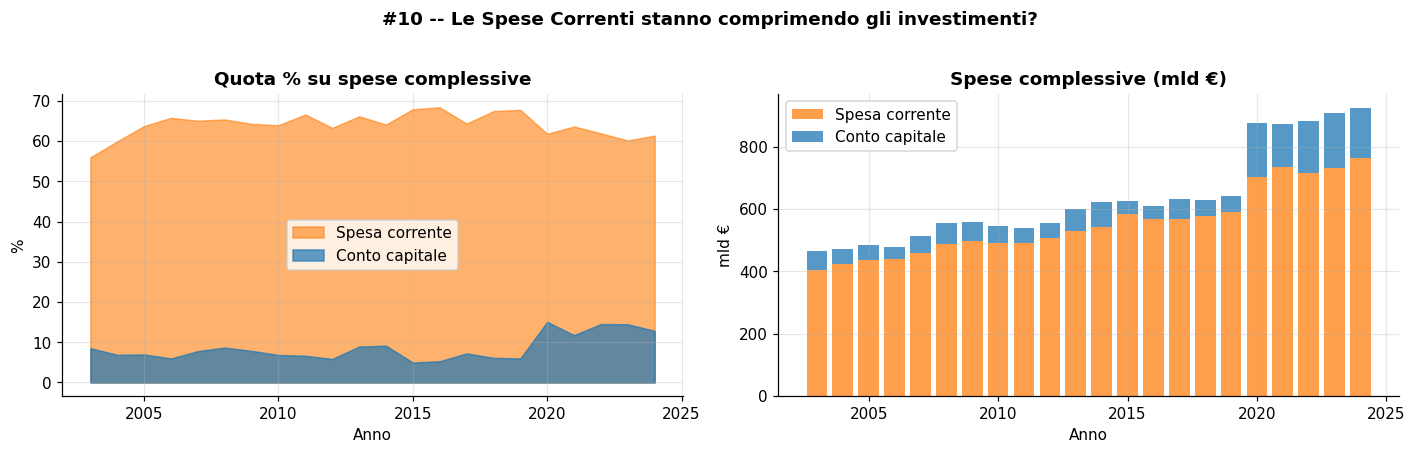

Salvato: spesa_corrente_vs_conto_capitale.png


In [ ]:
# ── #10 Composizione spesa ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].fill_between(df['anno'], df['quota_corrente'] * 100,
                     alpha=0.6, color=ORANGE, label='Spesa corrente')
axes[0].fill_between(df['anno'], df['quota_conto_capitale'] * 100,
                     alpha=0.7, color=BLUE, label='Conto capitale')
axes[0].set_title('Quota % su spese complessive', fontweight='bold')
axes[0].set_xlabel('Anno')
axes[0].set_ylabel('%')
axes[0].legend()

axes[1].bar(df['anno'], df['spese_correnti'] / 1e9,
            label='Spesa corrente', color=ORANGE, alpha=0.75)
axes[1].bar(df['anno'], df['spese_in_conto_capitale'] / 1e9,
            bottom=df['spese_correnti'] / 1e9,
            label='Conto capitale', color=BLUE, alpha=0.75)
axes[1].set_title('Spese complessive (mld €)', fontweight='bold')
axes[1].set_xlabel('Anno')
axes[1].set_ylabel('mld €')
axes[1].legend()

fig.suptitle('#10 -- Le Spese Correnti stanno comprimendo gli investimenti?',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('spesa_corrente_vs_conto_capitale.png', bbox_inches='tight')
plt.show()
print('Salvato: spesa_corrente_vs_conto_capitale.png')


## 6 - Bozza di risposta per #10


In [ ]:
def risposta_q10(df):
    quota_cap_media = df['quota_conto_capitale'].mean()
    quota_cur_media = df['quota_corrente'].mean()
    pre_cap  = df.loc[df['anno'] < 2015, 'quota_conto_capitale'].mean()
    post_cap = df.loc[df['anno'] >= 2015, 'quota_conto_capitale'].mean()
    min_idx  = df['quota_conto_capitale'].idxmin()
    max_idx  = df['quota_conto_capitale'].idxmax()
    anno_min = int(df.loc[min_idx, 'anno'])
    anno_max = int(df.loc[max_idx, 'anno'])
    val_min  = df.loc[min_idx, 'quota_conto_capitale']
    val_max  = df.loc[max_idx, 'quota_conto_capitale']
    anni_sotto_10 = int((df['quota_conto_capitale'] < 0.10).sum())

    lines = [
        '**Si: la spesa corrente e strutturalmente dominante e lascia poco spazio agli investimenti.**',
        '',
        f'Guardando la composizione della spesa nella serie {Y_MIN}–{Y_MAX}, il rapporto e chiaro:',
        f'la spesa corrente assorbe in media il **{pct(quota_cur_media)}** del totale,',
        f'mentre la spesa in conto capitale (investimenti) pesa in media **l’{pct(quota_cap_media)}**.',
        '',
        '**Numeri chiave:**',
        f'- Quota conto capitale piu alta: **{anno_max}** -> **{pct(val_max)}**',
        f'- Quota conto capitale piu bassa: **{anno_min}** -> **{pct(val_min)}**',
        f'- Anni in cui la quota conto capitale scende sotto il 10%: **{anni_sotto_10} su {N}**',
        f'- Media quota conto capitale pre-2015: **{pct(pre_cap)}** vs post-2015: **{pct(post_cap)}**',
        '',
        '**Come leggere questo dato:**',
        'La spesa corrente domina la struttura del bilancio e limita lo spazio relativo per gli investimenti.',
        'Il punto è che la spesa in conto capitale cresce meno della spesa corrente e il suo peso relativo',
        'rimane marginale. Nelle fasi di crisi la spesa in conto capitale (piu discrezionale) tende a',
        'cedere prima della spesa corrente (stipendi, pensioni, trasferimenti -- molto piu rigida).',
        '',
        'Il modello di spesa risulta strutturalmente orientato alla gestione ordinaria piu che allo sviluppo.',
        '',
        '> Analisi basata sul dataset CLEAN `saldi_storico.parquet` (OpenBDAP – Saldi storico Stato).',
        '> Valori nominali, bilancio dello Stato centrale. Periodo osservato: 2003–2024.',
        '> Per un approfondimento settoriale (sanita, istruzione, infrastrutture) servirebbero i dati per missione/programma.',
    ]
    return '\n'.join(lines)

print('Funzione risposta_q10 definita.')


Funzione risposta_q10 definita.


## 7 - Stampa bozza pronta per GitHub
Esegui questa cella -> copia il testo -> incolla nella Discussion corrispondente.


In [ ]:
DOMANDA = '#10 -- Le Spese Correnti stanno comprimendo gli investimenti?'
TESTO = risposta_q10(df)

SEP = '=' * 80
print(SEP)
print(f'  DISCUSSION {DOMANDA}')
print(SEP)
print(TESTO)


  DISCUSSION #10 -- Le Spese Correnti stanno comprimendo gli investimenti?
**Si: la spesa corrente e strutturalmente dominante e lascia poco spazio agli investimenti.**

Guardando la composizione della spesa nella serie 2003–2024, il rapporto e chiaro:
la spesa corrente assorbe in media il **64.0%** del totale,
mentre la spesa in conto capitale (investimenti) pesa in media **l’8.5%**.

**Numeri chiave:**
- Quota conto capitale piu alta: **2020** -> **15.1%**
- Quota conto capitale piu bassa: **2015** -> **4.9%**
- Anni in cui la quota conto capitale scende sotto il 10%: **17 su 22**
- Media quota conto capitale pre-2015: **7.5%** vs post-2015: **9.8%**

**Come leggere questo dato:**
La spesa corrente domina la struttura del bilancio e limita lo spazio relativo per gli investimenti.
Il punto è che la spesa in conto capitale cresce meno della spesa corrente e il suo peso relativo
rimane marginale. Nelle fasi di crisi la spesa in conto capitale (piu discrezionale) tende a
cedere prima del